# E2 — Write localization (write-wave along \(w\))

**Plan reference:** Phase 2, experiment E2.

**Question:** Where is preference for \(W\) written into the residual stream? Is it mostly the
input embed, a single mid-depth kick, or a **series of layer writes** (a write-wave) that
together mean \(W\)?

**Method:** direct logit attribution — project `attn_out` and `mlp_out` (per layer x position) onto
\(w = W_U[:,W] - W_U[:,C]\). Heatmaps and layer profiles show the **micro-writes**; cumsums /
channel splits describe the **composite**.

This is **not** a causal patching result (that is E4). It is also **not** about revision success
(E1 already: greedy answer stays \(W\)). Interpret against that baseline: *where is the sticking
preference written?*

**Reading note:** "Impulse" here is **not** required to be a brutish single-cell spike. A wave of
subtle per-layer pushes that cohere into "means \(W\)" still counts as impulse-shaped structure.
Absence of a mid-depth spike is **not** automatic failure.

## Locked design choices (from E1->E2 discussion)

1. **Primary meter:** raw DLA \(\langle \Delta, w \rangle\) onto the **final** unembed direction.
   Tuned-lens residual preference is a **secondary** check at the impulse position, not the
   attribution itself.
2. **Prompts:** lag-0 E0-style skeleton first; then mean over the E1 8-item bank.
3. **Embed vs extra:** report the W-token embed contribution separately; interesting structure is
   **post-embed** writes, not the input embedding itself.
4. **Norm:** primary = raw projection; secondary = unit-normalized writes
   \(\langle \Delta/\|\Delta\|, \hat{w} \rangle\) so late-layer size growth does not fake a ramp.

## Patterns (descriptive, not a spike test)

| Pattern | What it looks like |
|---|---|
| Mostly embed | Post-embed writes tiny vs embed at first \(W\) |
| Single kick | One layer (or head) dominates; neighbors quiet |
| Write-wave | Many layers contribute; cumsum builds; may land late |
| Distributed in position | Energy not confined to the W column alone |


In [1]:
# %pip install tuned-lens transformer-lens torch matplotlib numpy pandas

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformer_lens as tl
from dataclasses import dataclass
from tuned_lens.nn import TunedLens, Unembed

torch.set_grad_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


## 1. Load model + Tuned Lens

`fold_ln=False` so the Tuned Lens bridge matches E0. Primary DLA still uses raw residual-space
writes dotted with \(w\) (no LN). That answers "what was written along \(w\)"; LN-scaled final
logit contribution is a different (related) quantity and is not required for the shape question.


In [2]:
model = tl.HookedTransformer.from_pretrained(
    "gpt2",
    device=DEVICE,
    fold_ln=False,  # Tuned Lens bridge (E0 policy)
)
model.eval()
N_LAYERS = model.cfg.n_layers
D_MODEL = model.cfg.d_model
print(f"layers={N_LAYERS}  d_model={D_MODEL}")

tuned_lens = TunedLens.from_unembed_and_pretrained(
    unembed=Unembed(model),
    lens_resource_id="gpt2",
).to(DEVICE)
print("loaded pretrained TunedLens")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
layers=12  d_model=768


loaded pretrained TunedLens


## 2. Prompt bank (E1 items, lag 0)

Same forced-error family. Default cue = `Wait, let me recompute.` at lag 0.
We also build a length-matched **no_cue** control (filler replaces cue tokens) for a quick
compare — not an E1 redo, just to see whether cue text changes writes *after* \(W\).


In [3]:
@dataclass(frozen=True)
class Item:
    name: str
    a: int
    b: int
    W_str: str
    C_str: str


ITEMS = [
    Item("ops_12+15", 12, 15, " 25", " 27"),
    Item("ops_8+7", 8, 7, " 14", " 15"),
    Item("ops_11+12", 11, 12, " 22", " 23"),
    Item("ops_9+6", 9, 6, " 14", " 15"),
    Item("ops_13+14", 13, 14, " 26", " 27"),
    Item("ops_4+5", 4, 5, " 8", " 9"),
    Item("ops_16+10", 16, 10, " 24", " 26"),
    Item("ops_3+8", 3, 8, " 10", " 11"),
]

CUE = " Wait, let me recompute."
FILLER_UNIT = " ..."


def assert_single_token(s: str, label: str) -> int:
    tid = model.to_single_token(s)
    toks = model.to_str_tokens(s)
    assert len(toks) == 2 and toks[1] == s, f"{label}={s!r} not single token: {toks!r}"
    return tid


for it in ITEMS:
    assert_single_token(it.W_str, f"{it.name}.W")
    assert_single_token(it.C_str, f"{it.name}.C")
assert len(model.to_str_tokens(FILLER_UNIT)) == 2
print(f"checked {len(ITEMS)} items")


def n_tokens(text: str) -> int:
    return len(model.to_str_tokens(text)) - 1


def build_prompt(item: Item, with_cue: bool = True) -> str:
    # Lag-0 forced-error prompt. with_cue=False -> filler matched to cue length.
    prefix = f"{item.a} + {item.b} ={item.W_str}."
    suffix = f" {item.a} + {item.b} ="
    if with_cue:
        middle = CUE
    else:
        middle = FILLER_UNIT * n_tokens(CUE)
    return prefix + middle + suffix


demo = build_prompt(ITEMS[0], True)
print("demo:", repr(demo))
for i, t in enumerate(model.to_str_tokens(demo)):
    print(f"  {i:2d}  {t!r}")
print("no_cue:", repr(build_prompt(ITEMS[0], False)))


checked 8 items
demo: '12 + 15 = 25. Wait, let me recompute. 12 + 15 ='
   0  '<|endoftext|>'
   1  '12'
   2  ' +'
   3  ' 15'
   4  ' ='
   5  ' 25'
   6  '.'
   7  ' Wait'
   8  ','
   9  ' let'
  10  ' me'
  11  ' recomp'
  12  'ute'
  13  '.'
  14  ' 12'
  15  ' +'
  16  ' 15'
  17  ' ='
no_cue: '12 + 15 = 25. ... ... ... ... ... ... ... 12 + 15 ='


## 3. DLA helpers

For each forward pass we cache:

- `hook_embed` + `hook_pos_embed` (input write)
- `blocks.L.hook_attn_out`, `blocks.L.hook_mlp_out` (post-embed writes)

**Primary:** \(\mathrm{attr}(\Delta) = \Delta \cdot w\)

**Unit-normalized secondary:** \(\mathrm{attr}_u(\Delta) = (\Delta/\|\Delta\|) \cdot (w/\|w\|)\)
(cosine; ignores write magnitude)

**Tuned-lens secondary at impulse pos:** W-C score from `resid_pre` through Tuned Lens, depth curve
at the first \(W\) token (not at \(t^*\) — that is closer to E3).


In [4]:
def find_first_W_pos(str_toks: list[str], W_str: str) -> int:
    # First content occurrence of W after the first '=' (the forced wrong answer).
    eq_seen = False
    for i, t in enumerate(str_toks):
        if t == " =":
            eq_seen = True
            continue
        if eq_seen and t == W_str:
            return i
    raise ValueError(f"W token {W_str!r} not found after first '=': {str_toks}")


def find_t_star(str_toks: list[str]) -> int:
    eq = [i for i, t in enumerate(str_toks) if t == " ="]
    if not eq:
        raise ValueError("no ' =' token")
    return eq[-1]


def w_direction(W_str: str, C_str: str) -> torch.Tensor:
    W_id = model.to_single_token(W_str)
    C_id = model.to_single_token(C_str)
    return model.W_U[:, W_id] - model.W_U[:, C_id]


@dataclass
class DLAResult:
    item: str
    with_cue: bool
    prompt: str
    str_toks: list
    W_pos: int
    t_star: int
    final_score: float
    top1: str
    embed_attr: np.ndarray          # [seq]
    pos_embed_attr: np.ndarray      # [seq]
    attn_raw: np.ndarray            # [n_layers, seq]
    mlp_raw: np.ndarray             # [n_layers, seq]
    attn_unit: np.ndarray
    mlp_unit: np.ndarray
    tuned_at_W: np.ndarray          # [n_layers+1]
    random_attn_raw: np.ndarray | None
    w_norm: float


def run_dla(
    item: Item,
    with_cue: bool = True,
    n_random: int = 8,
    seed: int = 0,
) -> DLAResult:
    prompt = build_prompt(item, with_cue=with_cue)
    tokens = model.to_tokens(prompt)
    str_toks = model.to_str_tokens(prompt)
    assert tokens.shape[1] == len(str_toks)

    W_id = model.to_single_token(item.W_str)
    C_id = model.to_single_token(item.C_str)
    w = w_direction(item.W_str, item.C_str)
    w_hat = w / w.norm()
    W_pos = find_first_W_pos(str_toks, item.W_str)
    t_star = find_t_star(str_toks)

    logits, cache = model.run_with_cache(tokens)
    logit_vec = logits[0, t_star]
    final_score = float(logit_vec[W_id] - logit_vec[C_id])
    top1 = model.to_string([int(logit_vec.argmax())])

    emb = cache["hook_embed"][0]  # [seq, d]
    pemb = cache["hook_pos_embed"][0]
    embed_attr = (emb @ w).detach().float().cpu().numpy()
    pos_embed_attr = (pemb @ w).detach().float().cpu().numpy()

    seq = emb.shape[0]
    attn_raw = np.zeros((N_LAYERS, seq), dtype=np.float64)
    mlp_raw = np.zeros((N_LAYERS, seq), dtype=np.float64)
    attn_unit = np.zeros((N_LAYERS, seq), dtype=np.float64)
    mlp_unit = np.zeros((N_LAYERS, seq), dtype=np.float64)

    for L in range(N_LAYERS):
        a = cache[f"blocks.{L}.hook_attn_out"][0]
        m = cache[f"blocks.{L}.hook_mlp_out"][0]
        attn_raw[L] = (a @ w).detach().float().cpu().numpy()
        mlp_raw[L] = (m @ w).detach().float().cpu().numpy()
        a_n = a / (a.norm(dim=-1, keepdim=True) + 1e-8)
        m_n = m / (m.norm(dim=-1, keepdim=True) + 1e-8)
        attn_unit[L] = (a_n @ w_hat).detach().float().cpu().numpy()
        mlp_unit[L] = (m_n @ w_hat).detach().float().cpu().numpy()

    tuned_at_W = np.zeros(N_LAYERS + 1, dtype=np.float64)
    for L in range(N_LAYERS):
        hidden = cache[f"blocks.{L}.hook_resid_pre"]
        tl_logits = tuned_lens.forward(hidden, L)
        tuned_at_W[L] = float(tl_logits[0, W_pos, W_id] - tl_logits[0, W_pos, C_id])
    tuned_at_W[-1] = float(logits[0, W_pos, W_id] - logits[0, W_pos, C_id])

    rand_attn = None
    if n_random > 0:
        gen = torch.Generator(device=str(emb.device))
        gen.manual_seed(seed)
        rand_attn = np.zeros((N_LAYERS, seq), dtype=np.float64)
        for _ in range(n_random):
            r = torch.randn(D_MODEL, generator=gen, device=emb.device, dtype=w.dtype)
            r = r / r.norm() * w.norm()
            for L in range(N_LAYERS):
                a = cache[f"blocks.{L}.hook_attn_out"][0]
                rand_attn[L] += (a @ r).detach().float().cpu().numpy()
        rand_attn /= n_random

    return DLAResult(
        item=item.name,
        with_cue=with_cue,
        prompt=prompt,
        str_toks=str_toks,
        W_pos=W_pos,
        t_star=t_star,
        final_score=final_score,
        top1=top1,
        embed_attr=embed_attr,
        pos_embed_attr=pos_embed_attr,
        attn_raw=attn_raw,
        mlp_raw=mlp_raw,
        attn_unit=attn_unit,
        mlp_unit=mlp_unit,
        tuned_at_W=tuned_at_W,
        random_attn_raw=rand_attn,
        w_norm=float(w.norm()),
    )


def token_labels(str_toks: list[str], max_chars: int = 10) -> list[str]:
    out = []
    for i, t in enumerate(str_toks):
        s = t.replace("\n", "\\n")
        if len(s) > max_chars:
            s = s[: max_chars - 1] + "..."
        out.append(f"{i}:{s}")
    return out


base = run_dla(ITEMS[0], with_cue=True, n_random=8)
print("prompt:", base.prompt)
print(
    f"W_pos={base.W_pos} ({base.str_toks[base.W_pos]!r})  t*={base.t_star}  "
    f"final_score={base.final_score:+.3f}  top1={base.top1!r}"
)
print(
    f"embed@W · w = {base.embed_attr[base.W_pos]:+.3f}  "
    f"pos_embed@W · w = {base.pos_embed_attr[base.W_pos]:+.3f}"
)
print(
    f"sum attn@W = {base.attn_raw[:, base.W_pos].sum():+.3f}  "
    f"sum mlp@W = {base.mlp_raw[:, base.W_pos].sum():+.3f}"
)


prompt: 12 + 15 = 25. Wait, let me recompute. 12 + 15 =
W_pos=5 (' 25')  t*=17  final_score=+4.194  top1=' 25'
embed@W · w = +1.411  pos_embed@W · w = +0.062
sum attn@W = +48.218  sum mlp@W = +37.841


## 4. Baseline heatmaps (single prompt: `12+15`, with cue)

Three panels: attn writes, MLP writes, and their sum. Dashed line = first \(W\);
dotted line = \(t^*\) (final ` =`).


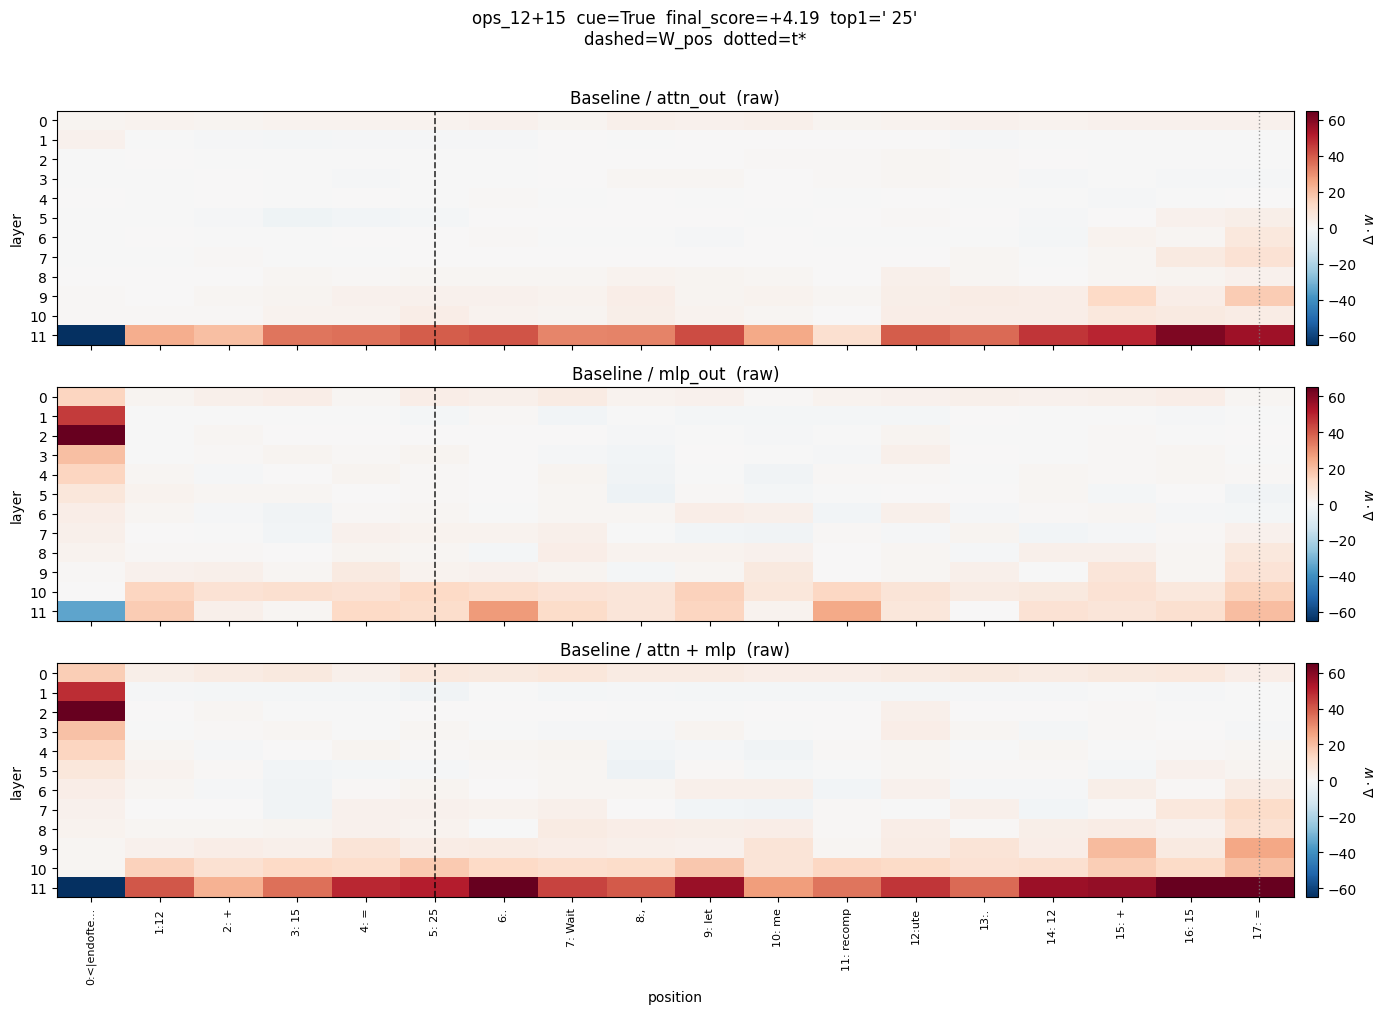

In [5]:
def plot_write_heatmaps(res: DLAResult, mode: str = "raw", title_prefix: str = ""):
    if mode == "raw":
        attn, mlp = res.attn_raw, res.mlp_raw
        cbar = r"$\Delta \cdot w$"
    elif mode == "unit":
        attn, mlp = res.attn_unit, res.mlp_unit
        cbar = r"$\cos(\Delta, w)$"
    else:
        raise ValueError(mode)

    total = attn + mlp
    mats = [attn, mlp, total]
    names = ["attn_out", "mlp_out", "attn + mlp"]
    labels = token_labels(res.str_toks)

    pooled = np.concatenate([m.ravel() for m in mats])
    vmax = float(np.percentile(np.abs(pooled), 99))
    vmax = max(vmax, 1e-6)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for ax, mat, name in zip(axes, mats, names):
        im = ax.imshow(
            mat,
            aspect="auto",
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axvline(res.W_pos, color="k", lw=1.2, ls="--", alpha=0.8)
        ax.axvline(res.t_star, color="gray", lw=1.0, ls=":", alpha=0.8)
        ax.set_ylabel("layer")
        ax.set_yticks(range(N_LAYERS))
        ax.set_title(f"{title_prefix}{name}  ({mode})")
        fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label=cbar)

    axes[-1].set_xticks(range(len(labels)))
    axes[-1].set_xticklabels(labels, rotation=90, fontsize=8)
    axes[-1].set_xlabel("position")
    fig.suptitle(
        f"{res.item}  cue={res.with_cue}  final_score={res.final_score:+.2f}  "
        f"top1={res.top1!r}\n"
        f"dashed=W_pos  dotted=t*",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_write_heatmaps(base, mode="raw", title_prefix="Baseline / ")


## 5. Embed vs post-embed at the impulse position

At the first \(W\) token: input embed contribution vs layer-wise attn/MLP writes.
If the story is "just reading the token," embed dominates and post-embed writes are small.
If there is an *extra* commitment write, some later layer spike should stand out.


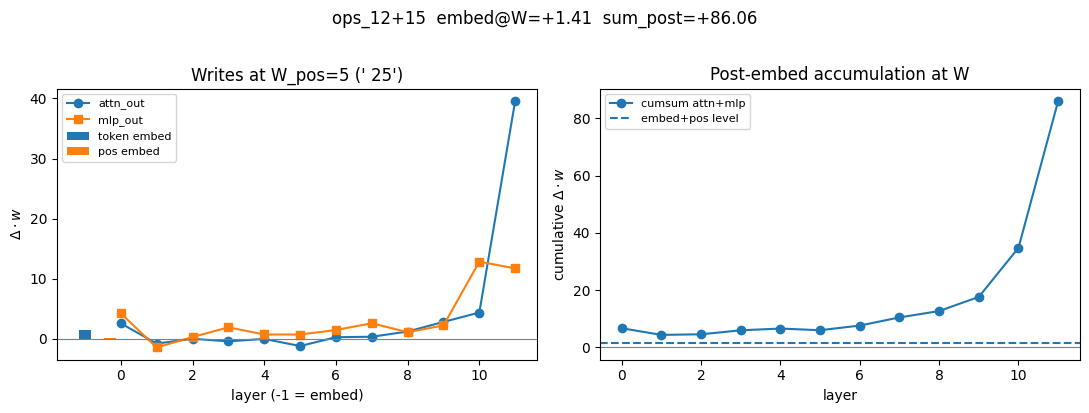

embed · w @ W:      +1.4111
pos_embed · w @ W:  +0.0620
sum attn · w @ W:   +48.2185
sum mlp · w @ W:    +37.8405
sum post · w @ W:   +86.0590
ratio |post|/(|embed|+eps): 60.985
peak |attn+mlp| layer @ W: L11 = +51.2794


In [6]:
def plot_impulse_profile(res: DLAResult):
    L = np.arange(N_LAYERS)
    p = res.W_pos
    emb = res.embed_attr[p]
    pemb = res.pos_embed_attr[p]
    post = res.attn_raw[:, p] + res.mlp_raw[:, p]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar([-1], [emb], width=0.35, color="C0", label="token embed")
    axes[0].bar([-0.3], [pemb], width=0.35, color="C1", label="pos embed")
    axes[0].plot(L, res.attn_raw[:, p], marker="o", label="attn_out")
    axes[0].plot(L, res.mlp_raw[:, p], marker="s", label="mlp_out")
    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].set_xlabel("layer (-1 = embed)")
    axes[0].set_ylabel(r"$\Delta \cdot w$")
    axes[0].set_title(f"Writes at W_pos={p} ({res.str_toks[p]!r})")
    axes[0].legend(fontsize=8)

    cum = np.cumsum(post)
    axes[1].plot(L, cum, marker="o", label="cumsum attn+mlp")
    axes[1].axhline(emb + pemb, color="C0", ls="--", label="embed+pos level")
    axes[1].axhline(0, color="gray", lw=0.8)
    axes[1].set_xlabel("layer")
    axes[1].set_ylabel(r"cumulative $\Delta \cdot w$")
    axes[1].set_title("Post-embed accumulation at W")
    axes[1].legend(fontsize=8)

    fig.suptitle(f"{res.item}  embed@W={emb:+.2f}  sum_post={post.sum():+.2f}", y=1.02)
    fig.tight_layout()
    plt.show()

    print(f"embed · w @ W:      {emb:+.4f}")
    print(f"pos_embed · w @ W:  {pemb:+.4f}")
    print(f"sum attn · w @ W:   {res.attn_raw[:, p].sum():+.4f}")
    print(f"sum mlp · w @ W:    {res.mlp_raw[:, p].sum():+.4f}")
    print(f"sum post · w @ W:   {post.sum():+.4f}")
    print(f"ratio |post|/(|embed|+eps): {abs(post.sum()) / (abs(emb) + 1e-8):.3f}")
    peak_L = int(np.argmax(np.abs(post)))
    print(f"peak |attn+mlp| layer @ W: L{peak_L} = {post[peak_L]:+.4f}")


plot_impulse_profile(base)


## 6. Secondary — unit-normalized heatmaps

Same layout as §4, but cosine of write with \(w\). A late-layer ramp that disappears here was
mostly norm growth; a spike that survives is directionally aligned, not just large.


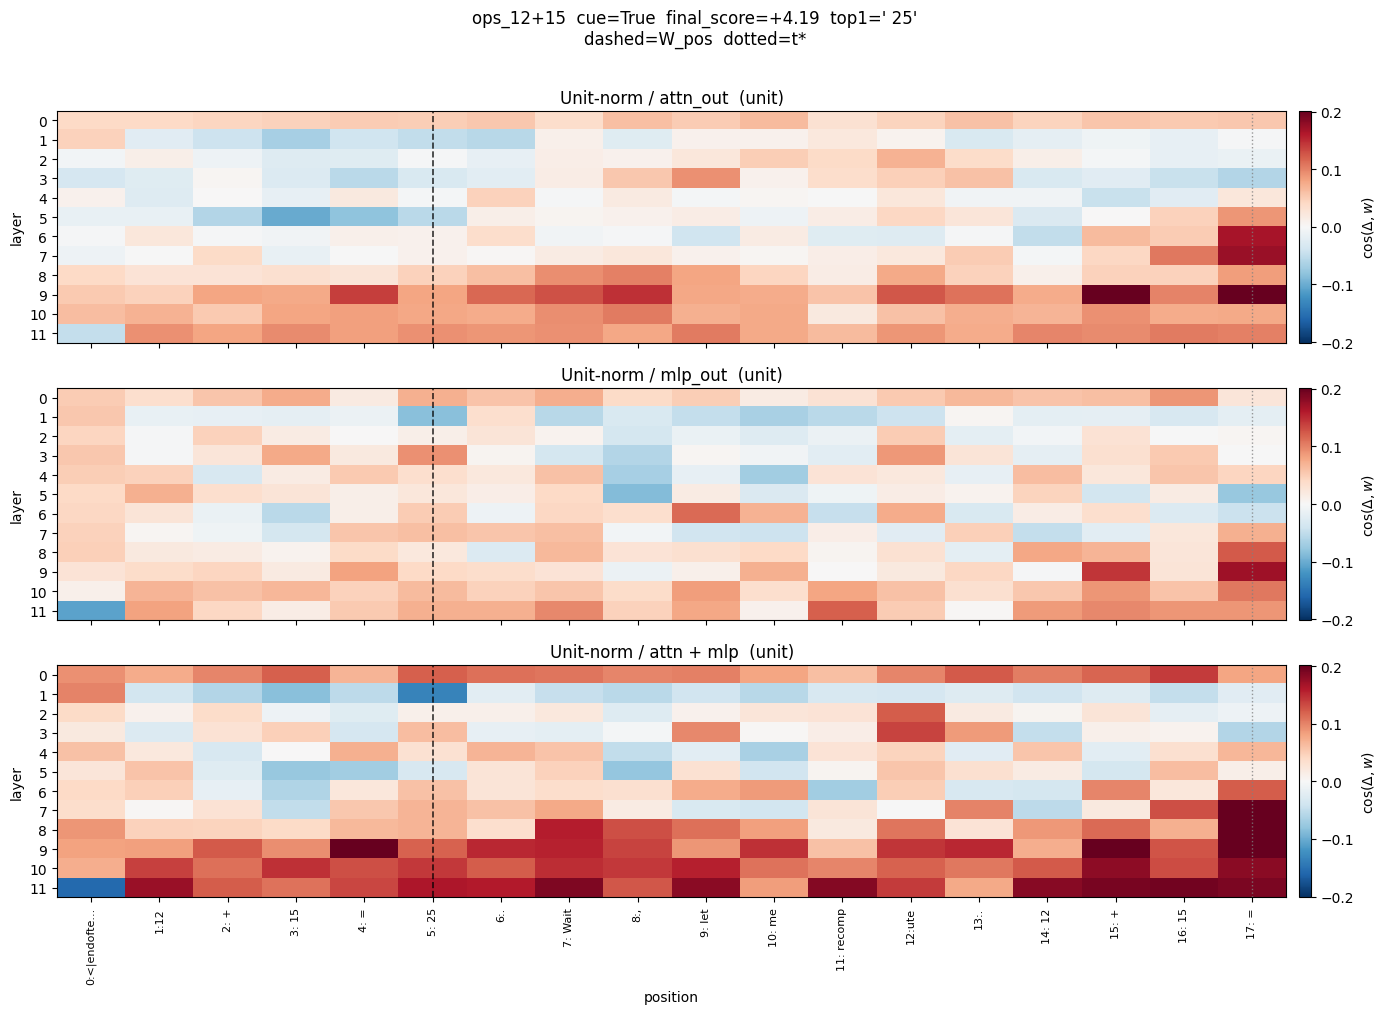

In [7]:
plot_write_heatmaps(base, mode="unit", title_prefix="Unit-norm / ")


## 7. Secondary — Tuned Lens at the impulse position

Depth curve of W-C preference **at the first \(W\) token** (`resid_pre` through Tuned Lens, plus
true next-token logits at that position). This is a *read* of residual preference mid-stream,
not a write attribution. Useful cross-check: does preference at \(W\) emerge around the same
depths where DLA shows large post-embed writes?


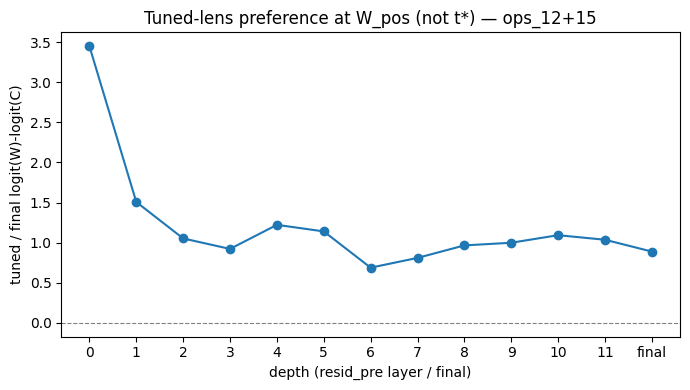

tuned_at_W: [3.45  1.506 1.052 0.921 1.221 1.14  0.687 0.809 0.965 0.998 1.092 1.035
 0.888]


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(N_LAYERS + 1), base.tuned_at_W, marker="o")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xticks(range(N_LAYERS + 1))
ax.set_xticklabels([str(i) for i in range(N_LAYERS)] + ["final"])
ax.set_xlabel("depth (resid_pre layer / final)")
ax.set_ylabel("tuned / final logit(W)-logit(C)")
ax.set_title(f"Tuned-lens preference at W_pos (not t*) — {base.item}")
plt.tight_layout()
plt.show()
print("tuned_at_W:", np.round(base.tuned_at_W, 3))


## 8. Control — random direction (baseline prompt)

Mean `attn_out · r` over norm-matched random \(r\). Structure that appears here is not
W-C-specific. Compare magnitude scale to §4.


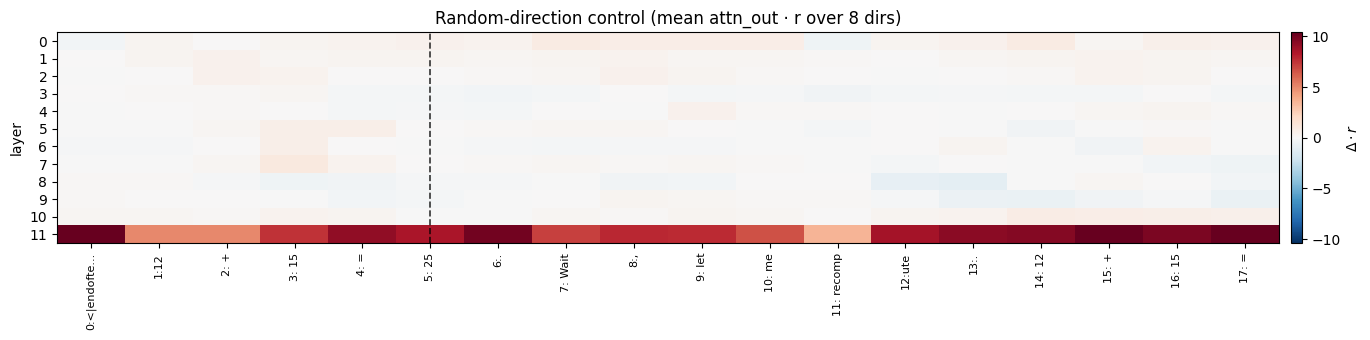

mean |attn·w|=5.2435  mean |attn·r|=1.0539


In [9]:
assert base.random_attn_raw is not None
fig, ax = plt.subplots(figsize=(14, 3.5))
vmax = float(np.percentile(np.abs(base.random_attn_raw), 99))
vmax = max(vmax, 1e-6)
im = ax.imshow(
    base.random_attn_raw,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest",
)
ax.axvline(base.W_pos, color="k", lw=1.2, ls="--", alpha=0.8)
ax.set_ylabel("layer")
ax.set_yticks(range(N_LAYERS))
labels = token_labels(base.str_toks)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_title("Random-direction control (mean attn_out · r over 8 dirs)")
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label=r"$\Delta \cdot r$")
fig.tight_layout()
plt.show()
print(
    f"mean |attn·w|={np.abs(base.attn_raw).mean():.4f}  "
    f"mean |attn·r|={np.abs(base.random_attn_raw).mean():.4f}"
)


## 9. Cue vs no_cue on the same item

Under causal masking, writes at positions \(\le W\) **cannot** depend on the later cue, so
attn/mlp at the impulse should match. Differences belong to cue / later positions
(descriptive only; overwrite-toward-C is E7).


max |d attn| on prefix<=W: 0.00e+00
max |d mlp|  on prefix<=W: 0.00e+00
(expect ~0: causal writes at/before W cannot depend on later cue)


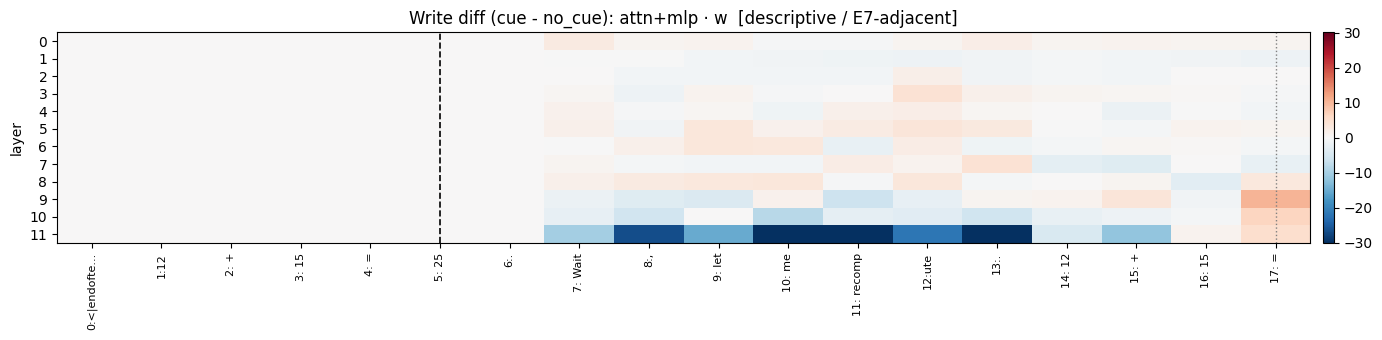

final_score cue=+4.194  no_cue=+3.003


In [10]:
base_nocue = run_dla(ITEMS[0], with_cue=False, n_random=0)
assert base.W_pos == base_nocue.W_pos
n_prefix = base.W_pos + 1
diff_attn = base.attn_raw[:, :n_prefix] - base_nocue.attn_raw[:, :n_prefix]
diff_mlp = base.mlp_raw[:, :n_prefix] - base_nocue.mlp_raw[:, :n_prefix]
print(f"max |d attn| on prefix<=W: {np.abs(diff_attn).max():.2e}")
print(f"max |d mlp|  on prefix<=W: {np.abs(diff_mlp).max():.2e}")
print("(expect ~0: causal writes at/before W cannot depend on later cue)")

assert base.attn_raw.shape == base_nocue.attn_raw.shape
d_total = (base.attn_raw + base.mlp_raw) - (base_nocue.attn_raw + base_nocue.mlp_raw)

fig, ax = plt.subplots(figsize=(14, 3.5))
vmax = float(np.percentile(np.abs(d_total), 99))
vmax = max(vmax, 1e-6)
im = ax.imshow(
    d_total, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest"
)
ax.axvline(base.W_pos, color="k", lw=1.2, ls="--")
ax.axvline(base.t_star, color="gray", lw=1.0, ls=":")
labels = token_labels(base.str_toks)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("layer")
ax.set_yticks(range(N_LAYERS))
ax.set_title("Write diff (cue - no_cue): attn+mlp · w  [descriptive / E7-adjacent]")
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
fig.tight_layout()
plt.show()
print(f"final_score cue={base.final_score:+.3f}  no_cue={base_nocue.final_score:+.3f}")


## 10. Multi-item aggregate (E1 bank, lag-0 + cue)

Align each item on the first \(W\) and crop a relative window \([W-4, W+8]\).
Mean attn+mlp raw writes across items. Also tabulate embed vs post-embed stats.


done ops_12+15  score=+4.19  peak=L11


done ops_8+7  score=+2.44  peak=L11


done ops_11+12  score=+1.87  peak=L11


done ops_9+6  score=+2.77  peak=L11


done ops_13+14  score=+1.26  peak=L5


done ops_4+5  score=+2.11  peak=L11


done ops_16+10  score=+4.49  peak=L11


done ops_3+8  score=+2.52  peak=L11
     item  final_score top1  embed_w  pos_embed_w  sum_attn_w  sum_mlp_w  sum_post_w  abs_post_over_abs_embed  peak_layer  peak_post  tuned_L0  tuned_final_at_W
ops_12+15       +4.194   25   +1.411       +0.062     +48.218    +37.841     +86.059                  +60.985          11    +51.279    +3.450            +0.888
  ops_8+7       +2.444   14   +1.197       +0.047     -22.391    -13.987     -36.378                  +30.381          11    -27.403    +2.786            +0.214
ops_11+12       +1.869   22   +0.791       +0.056      -6.678     -4.086     -10.764                  +13.608          11     -5.162    +1.578            -0.222
  ops_9+6       +2.768   14   +1.197       +0.047     -21.739    -14.134     -35.873                  +29.959          11    -27.472    +2.786            +0.272
ops_13+14       +1.263   26   +0.785       +0.070      -5.737     +2.095      -3.642                   +4.637           5     -1.424    +2.091            +0.08

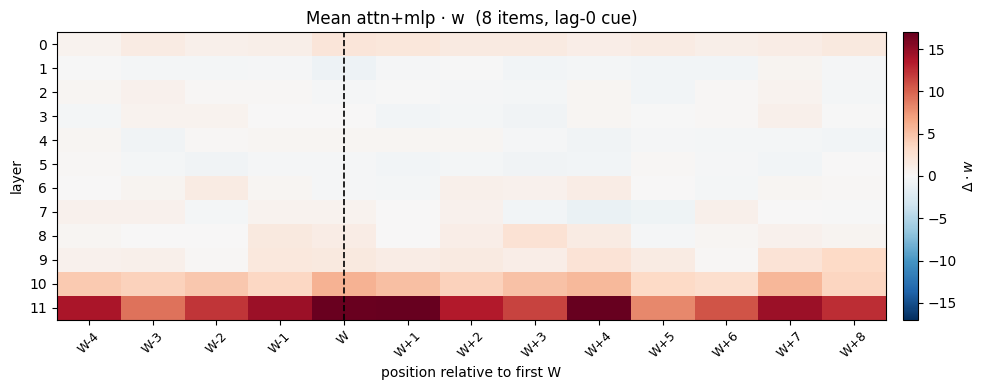

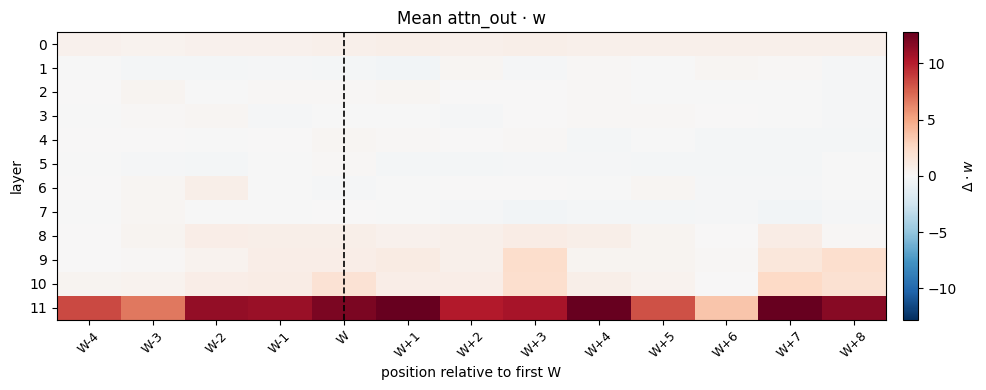

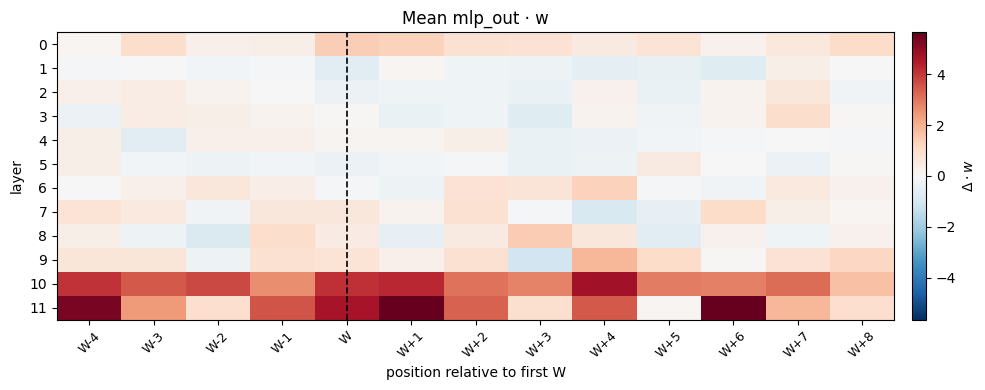

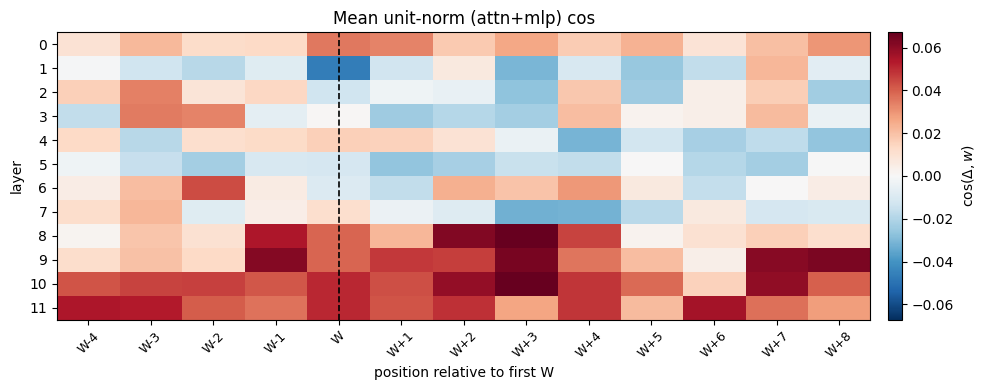

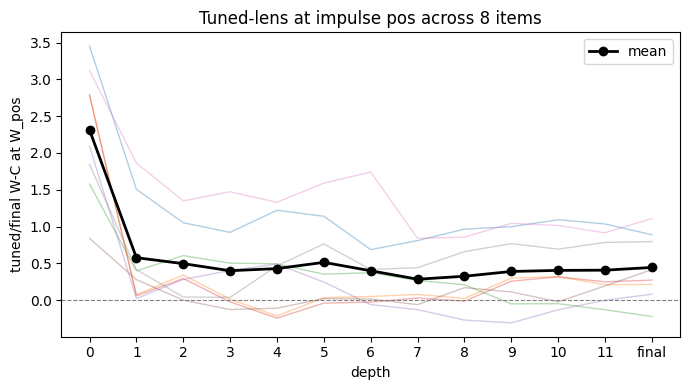


Aggregate peaks:
        item   embed_w  sum_post_w  abs_post_over_abs_embed  peak_layer  \
0  ops_12+15  1.411143   86.058981                60.985293          11   
1    ops_8+7  1.197381  -36.377949                30.381267          11   
2  ops_11+12  0.791009  -10.764147                13.608118          11   
3    ops_9+6  1.197381  -35.872530                29.959163          11   
4  ops_13+14  0.785422   -3.642010                 4.637011           5   
5    ops_4+5  1.044617   15.451197                14.791252          11   
6  ops_16+10  2.091935   95.057918                45.440194          11   
7    ops_3+8  1.304112  106.819144                81.909459          11   

   peak_post  
0  51.279400  
1 -27.403324  
2  -5.162245  
3 -27.472244  
4  -1.423631  
5  11.422234  
6  61.142076  
7  70.160793  

mean |post|/|embed| = 35.214  median peak_layer = 11.0


In [11]:
LEFT, RIGHT = 4, 8


def window_stack(mats, w_positions, left, right):
    width = left + 1 + right
    out = np.full((len(mats), mats[0].shape[0], width), np.nan, dtype=np.float64)
    for i, (mat, wp) in enumerate(zip(mats, w_positions)):
        for rel_i, col in enumerate(range(-left, right + 1)):
            j = wp + col
            if 0 <= j < mat.shape[1]:
                out[i, :, rel_i] = mat[:, j]
    return out


summary_rows = []
attn_mats, mlp_mats, unit_total_mats, w_positions = [], [], [], []
tuned_curves = []

for item in ITEMS:
    res = run_dla(item, with_cue=True, n_random=0)
    p = res.W_pos
    post = res.attn_raw[:, p] + res.mlp_raw[:, p]
    emb = float(res.embed_attr[p])
    peak_L = int(np.argmax(np.abs(post)))
    summary_rows.append(
        {
            "item": res.item,
            "final_score": res.final_score,
            "top1": res.top1,
            "embed_w": emb,
            "pos_embed_w": float(res.pos_embed_attr[p]),
            "sum_attn_w": float(res.attn_raw[:, p].sum()),
            "sum_mlp_w": float(res.mlp_raw[:, p].sum()),
            "sum_post_w": float(post.sum()),
            "abs_post_over_abs_embed": abs(float(post.sum())) / (abs(emb) + 1e-8),
            "peak_layer": peak_L,
            "peak_post": float(post[peak_L]),
            "tuned_L0": float(res.tuned_at_W[0]),
            "tuned_final_at_W": float(res.tuned_at_W[-1]),
        }
    )
    attn_mats.append(res.attn_raw)
    mlp_mats.append(res.mlp_raw)
    unit_total_mats.append(res.attn_unit + res.mlp_unit)
    w_positions.append(p)
    tuned_curves.append(res.tuned_at_W)
    print(f"done {res.item}  score={res.final_score:+.2f}  peak=L{peak_L}")

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

attn_w = window_stack(attn_mats, w_positions, LEFT, RIGHT)
mlp_w = window_stack(mlp_mats, w_positions, LEFT, RIGHT)
total_w = attn_w + mlp_w
mean_total = np.nanmean(total_w, axis=0)
mean_attn = np.nanmean(attn_w, axis=0)
mean_mlp = np.nanmean(mlp_w, axis=0)
mean_unit = np.nanmean(window_stack(unit_total_mats, w_positions, LEFT, RIGHT), axis=0)

rel_labels = [f"W{d:+d}" if d != 0 else "W" for d in range(-LEFT, RIGHT + 1)]


def plot_mean_heatmap(mat, title, cbar):
    vmax = float(np.nanpercentile(np.abs(mat), 99))
    vmax = max(vmax, 1e-6)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(
        mat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest"
    )
    ax.axvline(LEFT, color="k", lw=1.2, ls="--")
    ax.set_yticks(range(N_LAYERS))
    ax.set_ylabel("layer")
    ax.set_xticks(range(len(rel_labels)))
    ax.set_xticklabels(rel_labels, rotation=45, fontsize=9)
    ax.set_xlabel("position relative to first W")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=cbar)
    fig.tight_layout()
    plt.show()


plot_mean_heatmap(mean_total, "Mean attn+mlp · w  (8 items, lag-0 cue)", r"$\Delta \cdot w$")
plot_mean_heatmap(mean_attn, "Mean attn_out · w", r"$\Delta \cdot w$")
plot_mean_heatmap(mean_mlp, "Mean mlp_out · w", r"$\Delta \cdot w$")
plot_mean_heatmap(mean_unit, "Mean unit-norm (attn+mlp) cos", r"$\cos(\Delta, w)$")

# Tuned-lens depth curves at W across items
tuned_arr = np.stack(tuned_curves, axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
for i, row in enumerate(tuned_arr):
    ax.plot(range(N_LAYERS + 1), row, alpha=0.35, lw=1)
ax.plot(range(N_LAYERS + 1), tuned_arr.mean(0), marker="o", color="k", lw=2, label="mean")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xticks(range(N_LAYERS + 1))
ax.set_xticklabels([str(i) for i in range(N_LAYERS)] + ["final"])
ax.set_xlabel("depth")
ax.set_ylabel("tuned/final W-C at W_pos")
ax.set_title("Tuned-lens at impulse pos across 8 items")
ax.legend()
fig.tight_layout()
plt.show()

print("\nAggregate peaks:")
print(summary[["item", "embed_w", "sum_post_w", "abs_post_over_abs_embed", "peak_layer", "peak_post"]])
print(
    f"\nmean |post|/|embed| = {summary['abs_post_over_abs_embed'].mean():.3f}  "
    f"median peak_layer = {summary['peak_layer'].median():.1f}"
)


## 11. Read guide (wave framing)

1. **Embed vs post-embed:** is commitment mostly "reading the token," or do layers add material writes?
2. **Wave shape at W:** cumsum of micro-writes — early flat then late build, steady ramp, or one kick?
3. **Channels:** attn vs MLP as parallel micro-impulse streams (need not be equal).
4. **Norm check:** does unit-cosine keep the same late-depth / positional story?
5. **Stability:** 8-item mean vs baseline; watch for sign flips of raw post-embed at W across items.
6. **Cue:** prefix writes identical (sanity); post-W diffs are E7-adjacent only.

E2 describes the **write-wave along \(w\)**. Whether that wave **lands** as usable support at \(t^*\)
is E3. Causal tests (E4/E5) should target landing depth / write *sets*, not one heatmap peak.


In [12]:
# Auto-summary from the multi-item table (edit narrative after looking at heatmaps).
print("=== E2 auto-summary (numbers only) ===")
print(f"items: {len(summary)}")
print(f"mean final_score @ t*: {summary['final_score'].mean():+.3f}")
print(f"mean embed·w @ W:      {summary['embed_w'].mean():+.3f}")
print(f"mean sum_post·w @ W:   {summary['sum_post_w'].mean():+.3f}")
print(f"mean |post|/|embed|:   {summary['abs_post_over_abs_embed'].mean():.3f}")
print("peak_layer value counts:")
print(summary["peak_layer"].value_counts().sort_index().to_string())

# Fraction of |post| captured by the single peak layer
frac_peak = summary["peak_post"].abs() / (summary["sum_post_w"].abs() + 1e-8)
print(f"mean |peak|/|sum_post|: {frac_peak.mean():.3f}  (high => localized in depth)")

# Spatial concentration of mean |attn+mlp| in the W-aligned window:
abs_mean = np.nanmean(np.abs(total_w), axis=0)  # [layer, rel]
# energy at W column vs full window
e_W = abs_mean[:, LEFT].sum()
e_all = abs_mean.sum()
print(f"mean |write| mass at W col / window: {e_W / (e_all + 1e-8):.3f}")


=== E2 auto-summary (numbers only) ===
items: 8
mean final_score @ t*: +2.708
mean embed·w @ W:      +1.228
mean sum_post·w @ W:   +27.091
mean |post|/|embed|:   35.214
peak_layer value counts:
peak_layer
5     1
11    7
mean |peak|/|sum_post|: 0.628  (high => localized in depth)
mean |write| mass at W col / window: 0.088


## 12. Light polish — wave descriptors at first \(W\)

Descriptive only (no new causal claim):

1. **Per-layer signed fraction** of post-embed write at \(W\):  
   \(f_L = (\mathrm{attn}_L+\mathrm{mlp}_L) / \sum_{L'}|\mathrm{attn}_{L'}+\mathrm{mlp}_{L'}|\)  
   (signed numerator, L1-normalized denominator — shows which layers carry the wave).
2. **Cumsum curves** of attn, MLP, and total at \(W\) across the 8 items.
3. **Channel split:** mean |attn| vs |mlp| share of |post| at \(W\).

These support the write-wave reading for the E2 session freeze and hand off landing questions to E3.

     item  sum_attn  sum_mlp  sum_post  attn_share_of_L1  mlp_share_of_L1  L0_L5_L1_frac  L6_L11_L1_frac  L9_L11_L1_frac  peak_layer
ops_12+15   +48.218  +37.841   +86.059            +0.583           +0.444         +0.129          +0.871          +0.798          11
  ops_8+7   -22.391  -13.987   -36.378            +0.652           +0.394         +0.134          +0.866          +0.797          11
ops_11+12    -6.678   -4.086   -10.764            +0.814           +0.690         +0.145          +0.855          +0.653          11
  ops_9+6   -21.739  -14.134   -35.873            +0.649           +0.409         +0.129          +0.871          +0.802          11
ops_13+14    -5.737   +2.095    -3.642            +0.687           +1.033         +0.464          +0.536          +0.166           5
  ops_4+5   +11.531   +3.920   +15.451            +0.591           +0.638         +0.118          +0.882          +0.787          11
ops_16+10   +57.025  +38.033   +95.058            +0.579           +0

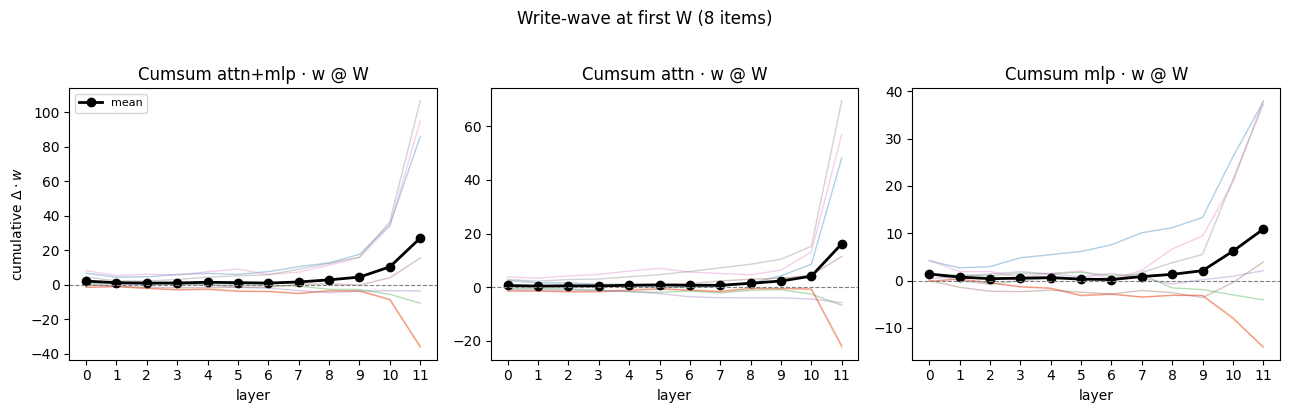

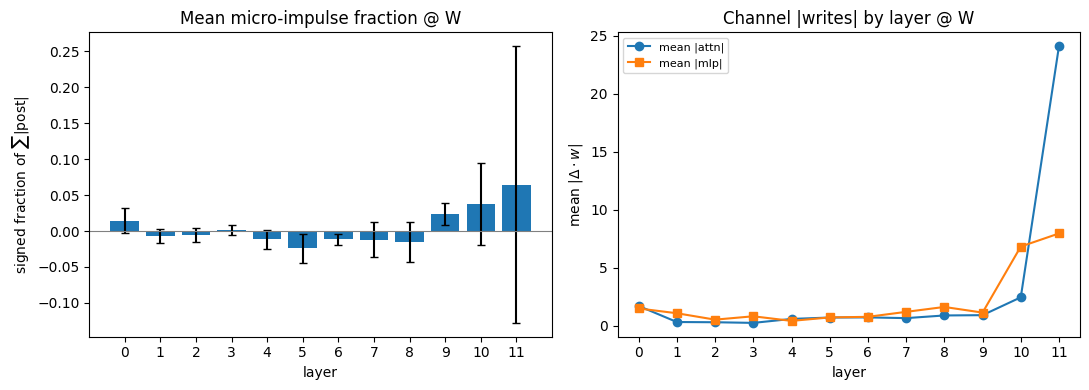

mean signed fraction by layer: [ 0.014 -0.007 -0.006  0.002 -0.012 -0.024 -0.011 -0.012 -0.015  0.023
  0.038  0.065]
Note: raw signed cumsums can cancel across items; L1 fractions + |channel| curves are the stabler wave descriptors.


In [13]:
# Rebuild per-item layer profiles at W (uses same run_dla as §10; n_random=0).
layer_attn = np.zeros((len(ITEMS), N_LAYERS), dtype=np.float64)
layer_mlp = np.zeros((len(ITEMS), N_LAYERS), dtype=np.float64)
item_names = []

for i, item in enumerate(ITEMS):
    res = run_dla(item, with_cue=True, n_random=0)
    p = res.W_pos
    layer_attn[i] = res.attn_raw[:, p]
    layer_mlp[i] = res.mlp_raw[:, p]
    item_names.append(res.item)

layer_total = layer_attn + layer_mlp
L1 = np.abs(layer_total).sum(axis=1, keepdims=True) + 1e-8
frac = layer_total / L1  # signed fraction of L1 mass

# --- Table: channel shares + depth concentration ---
polish_rows = []
for i, name in enumerate(item_names):
    post = layer_total[i]
    a_sum = float(layer_attn[i].sum())
    m_sum = float(layer_mlp[i].sum())
    abs_post = float(np.abs(post).sum())
    polish_rows.append(
        {
            "item": name,
            "sum_attn": a_sum,
            "sum_mlp": m_sum,
            "sum_post": float(post.sum()),
            "attn_share_of_L1": float(np.abs(layer_attn[i]).sum() / abs_post),
            "mlp_share_of_L1": float(np.abs(layer_mlp[i]).sum() / abs_post),
            "L0_L5_L1_frac": float(np.abs(post[:6]).sum() / abs_post),
            "L6_L11_L1_frac": float(np.abs(post[6:]).sum() / abs_post),
            "L9_L11_L1_frac": float(np.abs(post[9:]).sum() / abs_post),
            "peak_layer": int(np.argmax(np.abs(post))),
        }
    )
polish = pd.DataFrame(polish_rows)
print(polish.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print(
    f"\nmean attn L1 share={polish['attn_share_of_L1'].mean():.3f}  "
    f"mlp L1 share={polish['mlp_share_of_L1'].mean():.3f}"
)
print(
    f"mean L0-5 / L6-11 / L9-11 L1 mass: "
    f"{polish['L0_L5_L1_frac'].mean():.3f} / "
    f"{polish['L6_L11_L1_frac'].mean():.3f} / "
    f"{polish['L9_L11_L1_frac'].mean():.3f}"
)

# --- Cumsum curves (total / attn / mlp) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
xs = np.arange(N_LAYERS)
for i, name in enumerate(item_names):
    axes[0].plot(xs, np.cumsum(layer_total[i]), alpha=0.35, lw=1)
    axes[1].plot(xs, np.cumsum(layer_attn[i]), alpha=0.35, lw=1)
    axes[2].plot(xs, np.cumsum(layer_mlp[i]), alpha=0.35, lw=1)
axes[0].plot(xs, np.cumsum(layer_total, axis=1).mean(0), "k-o", lw=2, label="mean")
axes[1].plot(xs, np.cumsum(layer_attn, axis=1).mean(0), "k-o", lw=2, label="mean")
axes[2].plot(xs, np.cumsum(layer_mlp, axis=1).mean(0), "k-o", lw=2, label="mean")
for ax, title in zip(
    axes,
    ["Cumsum attn+mlp · w @ W", "Cumsum attn · w @ W", "Cumsum mlp · w @ W"],
):
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("layer")
    ax.set_title(title)
    ax.set_xticks(xs)
axes[0].set_ylabel(r"cumulative $\Delta \cdot w$")
axes[0].legend(fontsize=8)
fig.suptitle("Write-wave at first W (8 items)", y=1.02)
fig.tight_layout()
plt.show()

# --- Mean signed fraction per layer ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mean_frac = frac.mean(0)
sem_frac = frac.std(0) / np.sqrt(len(ITEMS))
axes[0].bar(xs, mean_frac, yerr=sem_frac, capsize=3, color="C0")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_xlabel("layer")
axes[0].set_ylabel(r"signed fraction of $\sum|\mathrm{post}|$")
axes[0].set_title("Mean micro-impulse fraction @ W")
axes[0].set_xticks(xs)

# Attn vs MLP mean |write| by layer
axes[1].plot(xs, np.abs(layer_attn).mean(0), marker="o", label="mean |attn|")
axes[1].plot(xs, np.abs(layer_mlp).mean(0), marker="s", label="mean |mlp|")
axes[1].set_xlabel("layer")
axes[1].set_ylabel(r"mean $|\Delta \cdot w|$")
axes[1].set_title("Channel |writes| by layer @ W")
axes[1].set_xticks(xs)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print("mean signed fraction by layer:", np.round(mean_frac, 3))
print(
    "Note: raw signed cumsums can cancel across items; L1 fractions + |channel| "
    "curves are the stabler wave descriptors."
)